In [1]:
%env NU_SKYMAP_DIR=/data/ana/realtime/alert_catalog_v3/fits/
import sys

env: NU_SKYMAP_DIR=/data/ana/realtime/alert_catalog_v3/fits/


In [2]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import random

from alertstack.analyse import Analyse
from alertstack.fixed_catalogues.icecube_neutrino_alerts import (
    HealpixNeutrinoAlertCatalogue
)
from alertstack.scramble_catalogues.agn_radio_catalogue import (
    AstrogeoAGNCatalogue, AverageFluxWeightHypothesis
)

from alertstack.scramble_catalogues.flaires_catalogue import (
    FlairesCatalogue, FluencebolHypothesis
)
from scipy import interpolate
from scipy.optimize import bisect
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

/data/user/gsommani/test-venv-python3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def find_sens(
    catalog,
    hypos,
    nucat,
    min_E,
    cache_dir,
    old_res_path,
    fraction=0.3,
    n_steps=15,
    n_trials=50,
    progression_bar=True,
    tag="",
    max_workers=4,
    chunksize=4,
):
    additional_tag = f"{tag}_E_min_{min_E}"
    analysis = Analyse(
        catalog,
        hypos,
        nucat,
        cache_dir=cache_dir,
        min_E = min_E,
        clean_cache=False
    )
    analysis.set_injection_hypo(hypos[0], min_E)
    fs = [0. for i in range(n_trials)]
    min_frac = 0.0
    for step in np.linspace(min_frac, fraction, n_steps + 1)[1:]:
        fs += [step for _ in range(n_trials)]
    
    inputs = [(x, int(random.random() * 10 ** 8)) for x in fs]
    
    if not progression_bar:
        text_trap = io.StringIO()
        sys.stderr = text_trap
        t0 = time.time()
    results = process_map(
        analysis.run_trial_wrapper,
        inputs,
        max_workers=max_workers,
        chunksize=chunksize,
        )
    
    all_res = dict()
    
    # Combine results into nested dictionaries
    
    for fraction in sorted(list(set(fs))):
        mask = np.array(fs) == fraction
        cut_results = np.array(results)[mask]
        res_dict = cut_results[0]
        for entry in cut_results[1:]:
            for key, val in entry.items():
                res_dict[key] += val
    
        for key in res_dict.keys():
            res_dict[key] = np.array(res_dict[key])
        all_res[fraction] = res_dict
    
    analysis.all_res = all_res
    
    analysis.dump_results(additional_tag=additional_tag)

    results = glob.glob(analysis.cache_dir + "/" + additional_tag + "*")
    new_res = results[0]
    old_res = old_res_path
    
    with open(new_res, "rb") as f:
        new_res_dict = pickle.load(f)
    with open(old_res, "rb") as f:
        old_res_dict = pickle.load(f)
    
    sens_threshold = dict()
    for key, val in old_res_dict[0.].items():
        sens_threshold[key] = np.median(val)

    levels = [
        ("Background Median", sens_threshold),
    ]
    print(levels)
    
    above = dict()
    
    # Calculate for each step the fraction of trials that are above a certain threshold
    # and store the information in the 'above' dictionary
    for step, res in new_res_dict.items():
    
        bkgs = dict()
        temp = []
    
        for key, val in res.items():
            val = np.array(val)
    
            for name, thresh in levels:
                temp.append(np.sum(val > thresh[key])/float(len(val)))        
        above[step] = temp
    
    fracs = list(above.keys())
    sens = [list(above.values())[i][0] for i in range(len(fracs))]
    
    # Interpolate a curve to the data points of the fraction of trials above each threshold
    f1 = interpolate.interp1d(fracs, sens, kind='cubic')
    
    frs = np.linspace(min(fracs), max(fracs), 100)
    plt.scatter(fracs, sens, marker="o")
    plt.plot(frs, f1(frs))
    plt.axhline(0.9, color="red", linestyle="dotted")
    plt.axvline(0.012, color="black", linestyle="dotted")
    plt.show()
    plt.close()
    
    # Calculate average signalness and number of neutrino alerts
    tmp = [i.weight for i in analysis.fixed_sources]
    avg_signalness = np.mean(tmp)
    n_events = len(tmp)
    
    # Calculate flux needed to achieve sensitivity and discovery potential 
    print(
        "\n------- Sensitivity and discovery potential with "
        "{0} neutrino alerts (average signalness: {1:.1f} %, min_E: {2:.0f} TeV) --------\n".format(
            n_events, 100*avg_signalness, min_E
        )
    )
    
    x1 = bisect(
        lambda x: f1(x)-0.9,
        min_frac,
        fraction,
        xtol=1e-6
    )
    
    print("Sensitivity at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
                x1,(x1*avg_signalness)*n_events,n_events,(x1*avg_signalness)))
    print("\n----------------------------------------------------------------------------------------------------------\n")

    return x1

100%|██████████| 800/800 [06:02<00:00,  2.20it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_10.02026_01_19-10_12_43.pkl
[('Background Median', {'average_radio_flux_weight': 31.801552319929264})]


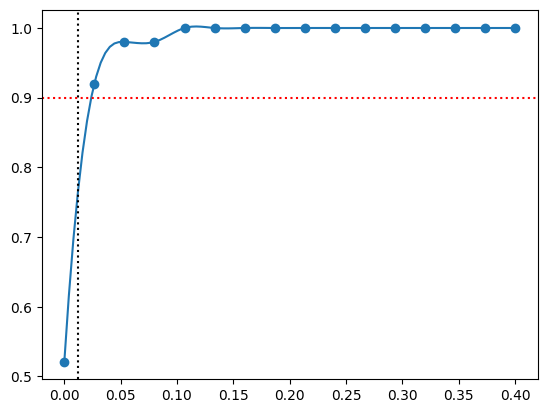


------- Sensitivity and discovery potential with 387 neutrino alerts (average signalness: 46.8 %, min_E: 10 TeV) --------

Sensitivity at 0.024 of flux, expectation of 4.3/387 = 0.01

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [06:08<00:00,  2.17it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_31.111111111111112026_01_19-10_18_59.pkl
[('Background Median', {'average_radio_flux_weight': 31.801552319929264})]


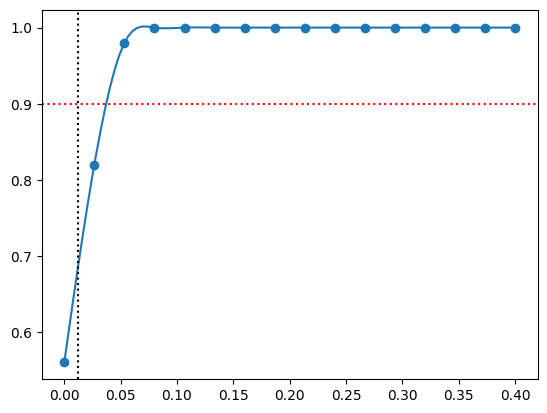


------- Sensitivity and discovery potential with 387 neutrino alerts (average signalness: 46.8 %, min_E: 31 TeV) --------

Sensitivity at 0.037 of flux, expectation of 6.7/387 = 0.02

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [06:05<00:00,  2.19it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_52.222222222222222026_01_19-10_25_12.pkl
[('Background Median', {'average_radio_flux_weight': 31.801552319929264})]


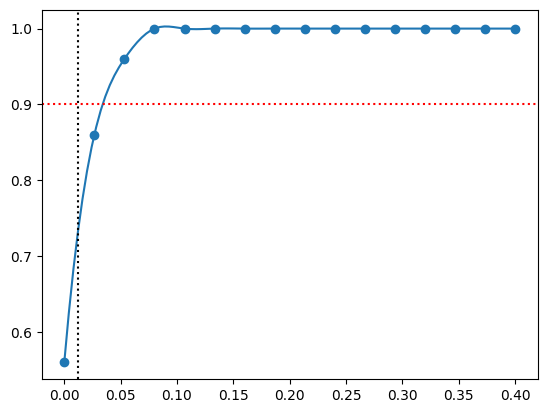


------- Sensitivity and discovery potential with 387 neutrino alerts (average signalness: 46.8 %, min_E: 52 TeV) --------

Sensitivity at 0.034 of flux, expectation of 6.2/387 = 0.02

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [06:00<00:00,  2.22it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_73.333333333333332026_01_19-10_31_20.pkl
[('Background Median', {'average_radio_flux_weight': 31.801552319929264})]


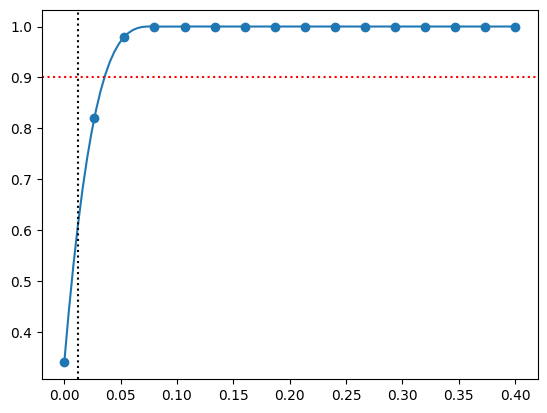


------- Sensitivity and discovery potential with 380 neutrino alerts (average signalness: 46.8 %, min_E: 73 TeV) --------

Sensitivity at 0.036 of flux, expectation of 6.3/380 = 0.02

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [05:52<00:00,  2.27it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_94.444444444444442026_01_19-10_37_20.pkl
[('Background Median', {'average_radio_flux_weight': 31.801552319929264})]


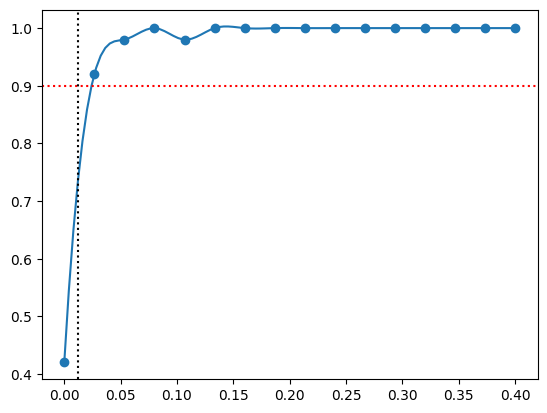


------- Sensitivity and discovery potential with 374 neutrino alerts (average signalness: 46.9 %, min_E: 94 TeV) --------

Sensitivity at 0.024 of flux, expectation of 4.2/374 = 0.01

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [04:42<00:00,  2.83it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_115.555555555555562026_01_19-10_42_11.pkl
[('Background Median', {'average_radio_flux_weight': 31.801552319929264})]


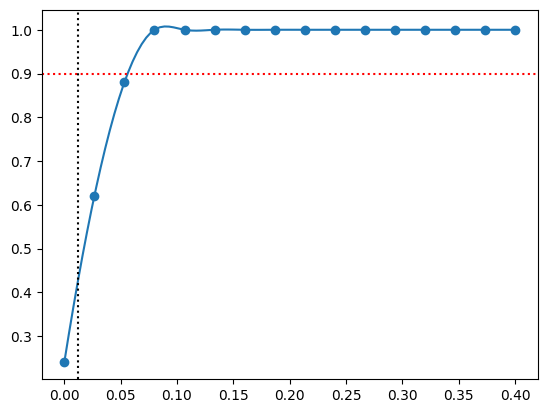


------- Sensitivity and discovery potential with 293 neutrino alerts (average signalness: 50.7 %, min_E: 116 TeV) --------

Sensitivity at 0.056 of flux, expectation of 8.3/293 = 0.03

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [03:50<00:00,  3.47it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_136.666666666666662026_01_19-10_46_10.pkl
[('Background Median', {'average_radio_flux_weight': 31.801552319929264})]


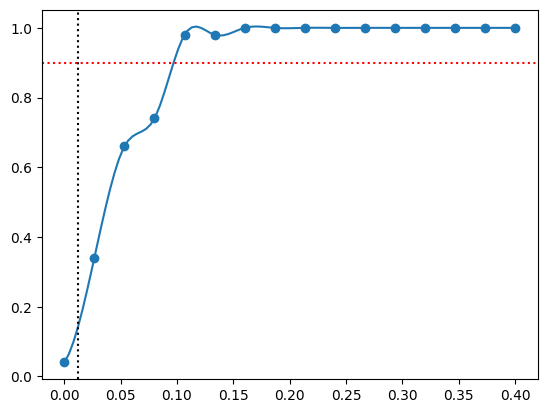


------- Sensitivity and discovery potential with 240 neutrino alerts (average signalness: 53.7 %, min_E: 137 TeV) --------

Sensitivity at 0.097 of flux, expectation of 12.5/240 = 0.05

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [02:59<00:00,  4.46it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_157.777777777777772026_01_19-10_49_17.pkl
[('Background Median', {'average_radio_flux_weight': 31.801552319929264})]


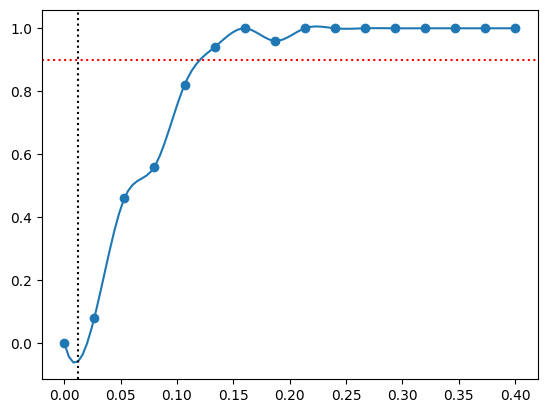


------- Sensitivity and discovery potential with 185 neutrino alerts (average signalness: 56.9 %, min_E: 158 TeV) --------

Sensitivity at 0.120 of flux, expectation of 12.7/185 = 0.07

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [02:06<00:00,  6.30it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_178.888888888888892026_01_19-10_51_32.pkl
[('Background Median', {'average_radio_flux_weight': 31.801552319929264})]


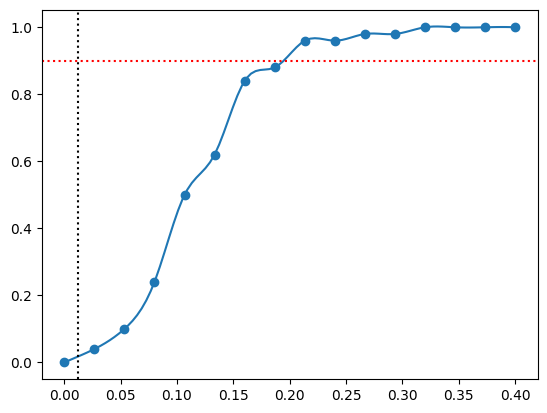


------- Sensitivity and discovery potential with 129 neutrino alerts (average signalness: 61.4 %, min_E: 179 TeV) --------

Sensitivity at 0.195 of flux, expectation of 15.4/129 = 0.12

----------------------------------------------------------------------------------------------------------



100%|██████████| 800/800 [01:32<00:00,  8.63it/s]


/data/user/gsommani/alertstack-icecube/radio_agn_E_min_200.02026_01_19-10_53_12.pkl
[('Background Median', {'average_radio_flux_weight': 31.801552319929264})]


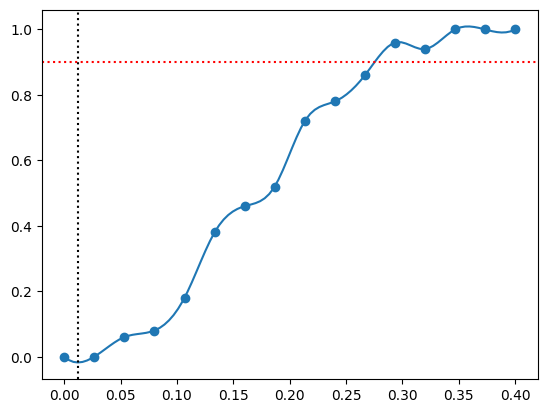


------- Sensitivity and discovery potential with 96 neutrino alerts (average signalness: 63.6 %, min_E: 200 TeV) --------

Sensitivity at 0.275 of flux, expectation of 16.8/96 = 0.18

----------------------------------------------------------------------------------------------------------



In [4]:
es = np.linspace(10,200,10)
sensitivities = []
for e in es:
    sensitivities.append(find_sens(    
        AstrogeoAGNCatalogue(),
        [AverageFluxWeightHypothesis],
        HealpixNeutrinoAlertCatalogue(),
        min_E = e,
        fraction = 0.4,
        cache_dir=os.getcwd(),
        old_res_path=(
            "/data/user/gsommani/New_Updated_Alerts_Stacking/examples/"
            "radio_agn_neutrino_alert/cache/2026_01_09-16_27_14.pkl"
        ),
        tag="radio_agn"
    ))

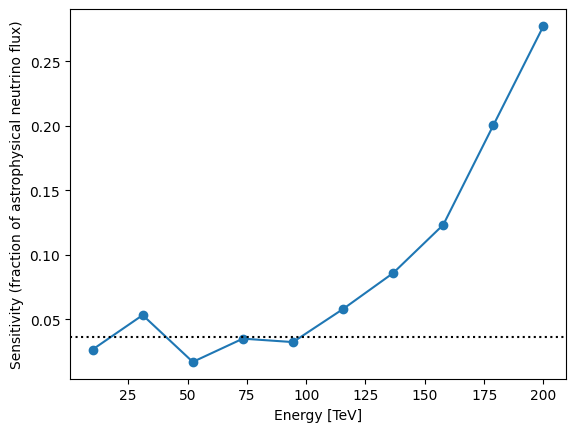

In [8]:
plt.plot(es, sensitivities, marker="o")
plt.axhline(0.036, color="black", linestyle="dotted", label="Analysis' sensitivity")
plt.xlabel("Energy [TeV]")
plt.ylabel("Sensitivity (fraction of astrophysical neutrino flux)")
plt.savefig("e_min_radio_agn", dpi=150)

Found 524 sources in total


100%|██████████| 1600/1600 [09:11<00:00,  2.90it/s]


[{'bolometric_fluence_weight': [3.2286773993205116]}, {'bolometric_fluence_weight': [1.121951950271491]}, {'bolometric_fluence_weight': [2.243926528498203]}, {'bolometric_fluence_weight': [4.193164450036064]}, {'bolometric_fluence_weight': [9.966787030547657]}, {'bolometric_fluence_weight': [1.8087674367425286]}, {'bolometric_fluence_weight': [3.6606328550564804]}, {'bolometric_fluence_weight': [2.261417919708525]}, {'bolometric_fluence_weight': [2.360691649157021]}, {'bolometric_fluence_weight': [6.905600292986536]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [3.0147363127800277]}, {'bolometric_fluence_weight': [2.5058187194486194]}, {'bolometric_fluence_weight': [0.5114335168089515]}, {'bolometric_fluence_weight': [8.744841303699046]}, {'bolometric_fluence_weight': [11.237410619095254]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [4.2407063780821375]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [0.0]}, {'bolom

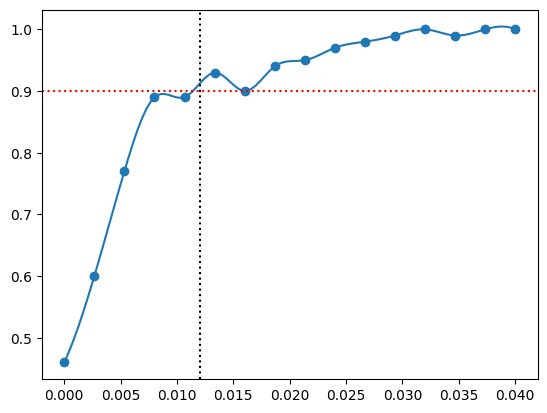


------- Sensitivity and discovery potential with 304 neutrino alerts (average signalness: 47.2 %, min_E: 50 TeV) --------

Sensitivity at 0.011 of flux, expectation of 1.6/304 = 0.01

----------------------------------------------------------------------------------------------------------

Found 524 sources in total


100%|██████████| 1600/1600 [09:11<00:00,  2.90it/s]


[{'bolometric_fluence_weight': [10.477850685801567]}, {'bolometric_fluence_weight': [9.998439867462]}, {'bolometric_fluence_weight': [5.82301371249782]}, {'bolometric_fluence_weight': [3.7452567555292244]}, {'bolometric_fluence_weight': [10.105054291760101]}, {'bolometric_fluence_weight': [6.4885120656985595]}, {'bolometric_fluence_weight': [3.7162657765401717]}, {'bolometric_fluence_weight': [12.412683182661757]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [1.8563839083834286]}, {'bolometric_fluence_weight': [2.8709128434479254]}, {'bolometric_fluence_weight': [1.1637237101737783]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [3.842088836475241]}, {'bolometric_fluence_weight': [0.6967448964115297]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [3.5983860515536104]}, {'bolometric_fluence_weight': [5.96091524673583]}, {'bolometric_fluence_weight': [5.1696827952312105]}, {'bolometric_fluence_weight': [0.1354231016897

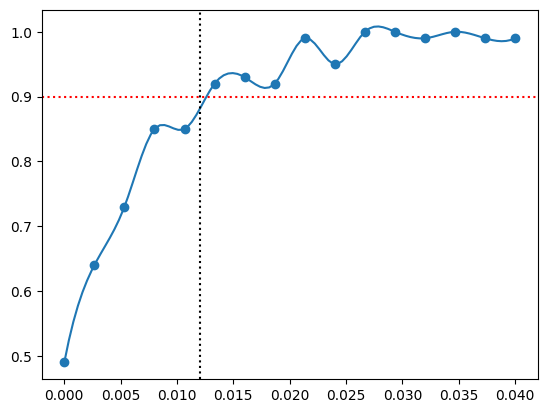


------- Sensitivity and discovery potential with 301 neutrino alerts (average signalness: 47.3 %, min_E: 61 TeV) --------

Sensitivity at 0.013 of flux, expectation of 1.8/301 = 0.01

----------------------------------------------------------------------------------------------------------

Found 524 sources in total


100%|██████████| 1600/1600 [09:07<00:00,  2.92it/s]


[{'bolometric_fluence_weight': [6.447180274146523]}, {'bolometric_fluence_weight': [4.936535471490959]}, {'bolometric_fluence_weight': [8.078686141353234]}, {'bolometric_fluence_weight': [2.2536156821901256]}, {'bolometric_fluence_weight': [4.3374975271943494]}, {'bolometric_fluence_weight': [2.6978554535893124]}, {'bolometric_fluence_weight': [0.8420706536331571]}, {'bolometric_fluence_weight': [7.806551592521008]}, {'bolometric_fluence_weight': [1.2186934012299295]}, {'bolometric_fluence_weight': [3.080347406231635]}, {'bolometric_fluence_weight': [14.32729536948707]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [3.761308826984175]}, {'bolometric_fluence_weight': [12.57445486146296]}, {'bolometric_fluence_weight': [0.8126547004492859]}, {'bolometric_fluence_weight': [1.2146624688093697]}, {'bolometric_fluence_weight': [11.657335197355762]}, {'bolometric_fluence_weight': [1.252926303239837]}, {'bolometric_fluence_weight': [5.79524180029097]}, {'bolometric_fluen

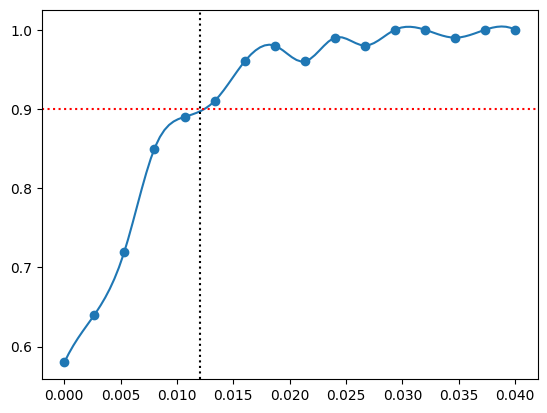


------- Sensitivity and discovery potential with 298 neutrino alerts (average signalness: 47.2 %, min_E: 72 TeV) --------

Sensitivity at 0.012 of flux, expectation of 1.7/298 = 0.01

----------------------------------------------------------------------------------------------------------

Found 524 sources in total


100%|██████████| 1600/1600 [09:05<00:00,  2.93it/s]


[{'bolometric_fluence_weight': [1.2616159701255012]}, {'bolometric_fluence_weight': [3.225911404073173]}, {'bolometric_fluence_weight': [2.0455716716437333]}, {'bolometric_fluence_weight': [9.589416385991662]}, {'bolometric_fluence_weight': [0.5336554025124715]}, {'bolometric_fluence_weight': [12.247932530766063]}, {'bolometric_fluence_weight': [2.044994625013144]}, {'bolometric_fluence_weight': [0.9947730723961471]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [0.11236499516932415]}, {'bolometric_fluence_weight': [10.020872186574248]}, {'bolometric_fluence_weight': [4.693361670524464]}, {'bolometric_fluence_weight': [2.0394876248343774]}, {'bolometric_fluence_weight': [2.5169400121551444]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [2.967230044548106]}, {'bolometric_fluence_weight': [5.0865014875593975]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [0.45212157956460597]}, {'bolometric_fluence_weight': [7.2522502

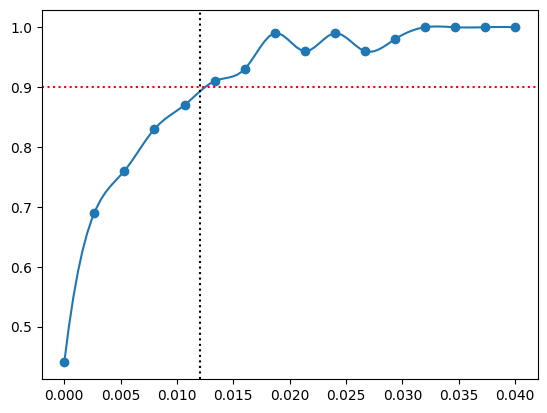


------- Sensitivity and discovery potential with 297 neutrino alerts (average signalness: 47.2 %, min_E: 83 TeV) --------

Sensitivity at 0.012 of flux, expectation of 1.8/297 = 0.01

----------------------------------------------------------------------------------------------------------

Found 524 sources in total


100%|██████████| 1600/1600 [08:42<00:00,  3.06it/s]


[{'bolometric_fluence_weight': [4.192384392813679]}, {'bolometric_fluence_weight': [3.1853248144146296]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [9.07794292801321]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [6.276702632810867]}, {'bolometric_fluence_weight': [2.2151429977067423]}, {'bolometric_fluence_weight': [2.5517030171329416]}, {'bolometric_fluence_weight': [3.1850930107156326]}, {'bolometric_fluence_weight': [1.7205126208757973]}, {'bolometric_fluence_weight': [0.23085936195451903]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [9.897796836758708]}, {'bolometric_fluence_weight': [3.538555625859826]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [3.910766537235582]}, {'bolometric_fluence_weight': [8.619455182346554]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [3.50347016037019]}, {'bolometric_fluence_weight': [7.13658

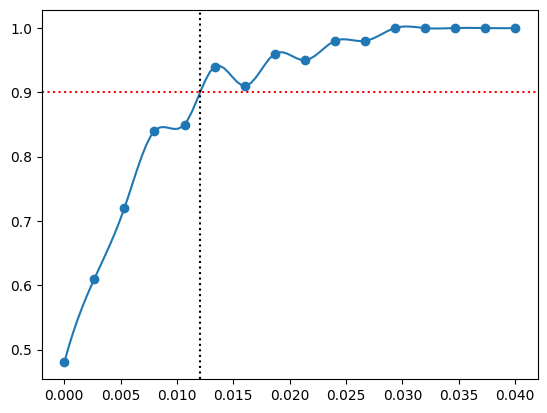


------- Sensitivity and discovery potential with 292 neutrino alerts (average signalness: 47.3 %, min_E: 94 TeV) --------

Sensitivity at 0.012 of flux, expectation of 1.7/292 = 0.01

----------------------------------------------------------------------------------------------------------

Found 524 sources in total


100%|██████████| 1600/1600 [08:42<00:00,  3.06it/s]


[{'bolometric_fluence_weight': [1.6299070687564998]}, {'bolometric_fluence_weight': [6.629193850354076]}, {'bolometric_fluence_weight': [9.698662981067313]}, {'bolometric_fluence_weight': [1.7268094045868618]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [1.4753110753355554]}, {'bolometric_fluence_weight': [3.119463942073674]}, {'bolometric_fluence_weight': [11.345901347180853]}, {'bolometric_fluence_weight': [2.148858558452493]}, {'bolometric_fluence_weight': [9.477927137221801]}, {'bolometric_fluence_weight': [6.888573499568088]}, {'bolometric_fluence_weight': [5.910833003430446]}, {'bolometric_fluence_weight': [4.8715379656099485]}, {'bolometric_fluence_weight': [3.2362062467446893]}, {'bolometric_fluence_weight': [3.552808447970121]}, {'bolometric_fluence_weight': [0.8619974651361249]}, {'bolometric_fluence_weight': [1.081241270174898]}, {'bolometric_fluence_weight': [10.290086964123985]}, {'bolometric_fluence_weight': [6.192966419422218]}, {'bolometric_flue

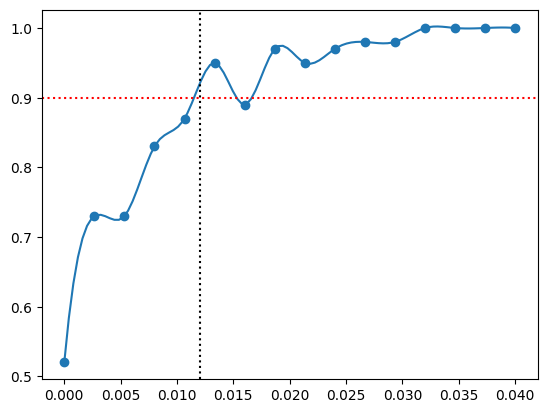


------- Sensitivity and discovery potential with 292 neutrino alerts (average signalness: 47.3 %, min_E: 106 TeV) --------

Sensitivity at 0.012 of flux, expectation of 1.6/292 = 0.01

----------------------------------------------------------------------------------------------------------

Found 524 sources in total


100%|██████████| 1600/1600 [06:57<00:00,  3.83it/s]


[{'bolometric_fluence_weight': [1.9164173189165499]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [5.020152232269295]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [6.954252024810478]}, {'bolometric_fluence_weight': [3.4753654824854276]}, {'bolometric_fluence_weight': [4.683459419557545]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [4.403026117998819]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [7.213003020445953]}, {'bolometric_fluence_weight': [2.697640181224749]}, {'bolometric_fluence_weight': [0.24827085331851828]}, {'bolometric_fluence_weight': [7.346054065832432]}, {'bolometric_fluence_weight': [3.5726023190980634]}, {'bolometric_fluence_weight': [13.726926510778473]}, {'bolometric_fluence_weight': [2.063208344756773]}, {'bolometric_fluence_weight': [12.856824694571884]}, {'bolometric_fluence_weight': [9.29541196338613]}, {'bolometric_fluence_weight': [1.573444705106502]}, {'bolomet

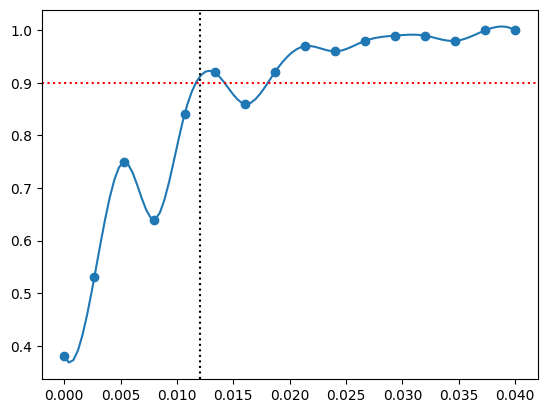


------- Sensitivity and discovery potential with 229 neutrino alerts (average signalness: 51.0 %, min_E: 117 TeV) --------

Sensitivity at 0.018 of flux, expectation of 2.1/229 = 0.01

----------------------------------------------------------------------------------------------------------

Found 524 sources in total


100%|██████████| 1600/1600 [06:21<00:00,  4.19it/s]


[{'bolometric_fluence_weight': [1.293748074074849]}, {'bolometric_fluence_weight': [0.03579617305560923]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [6.007538842521495]}, {'bolometric_fluence_weight': [5.3752182466632785]}, {'bolometric_fluence_weight': [2.906522782522159]}, {'bolometric_fluence_weight': [4.9335806328760405]}, {'bolometric_fluence_weight': [1.547628868677463]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [1.7894552312894765]}, {'bolometric_fluence_weight': [7.192734098907733]}, {'bolometric_fluence_weight': [10.954246812127218]}, {'bolometric_fluence_weight': [1.8634288271285038]}, {'bolometric_fluence_weight': [2.7562185721831045]}, {'bolometric_fluence_weight': [0.2424539823143544]}, {'bolometric_fluence_weight': [1.9483659904126263]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [0.0]}, {'bolometric_fluence_weight': [0.8124686820020622]}, {'bolometric_fluence_weight': [0.4509294279935597]}, {'b

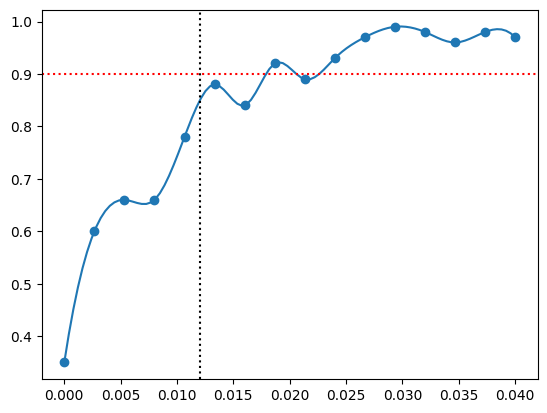


------- Sensitivity and discovery potential with 210 neutrino alerts (average signalness: 52.3 %, min_E: 128 TeV) --------

Sensitivity at 0.018 of flux, expectation of 2.0/210 = 0.01

----------------------------------------------------------------------------------------------------------

Found 524 sources in total


  7%|▋         | 109/1600 [00:25<04:21,  5.70it/s]

In [ ]:
es = np.logspace(np.log10(40),np.log10(500),10)
es = np.linspace(50,150,10)
sensitivities = []
for e in es:
    sensitivities.append(find_sens(    
        FlairesCatalogue(),
        [FluencebolHypothesis],
        HealpixNeutrinoAlertCatalogue(),
        min_E = e,
        fraction = 0.04,
        cache_dir=os.getcwd(),
        old_res_path=(
            "/data/user/gsommani/alertstack_results/flaires_n2000000_f0.07_s10.pkl"  
        ),
        tag="flaires_zoom",
        max_workers=4,
        chunksize=4,
        n_trials=100
    ))

In [5]:
obj = FlairesCatalogue()

Found 524 sources in total


In [8]:
obj.data

,Source_Name,ra_rad,dec_rad,ra_deg,dec_deg,t-peak,HW1mag,HW2mag,NEWS,AllWISE,...,FluenceW1,e_FluenceW1,FluenceW2,e_FluenceW2,Sep,PeakLbol,PeakTime,Ebol,Fluencebol,bkg_pdf
0,NGC 7392,5.985660,-0.359679,342.95308,-20.60808,57169.940000,8.532,8.467,NaN,NaN,...,0.003197,1.098000e-04,0.003862,6.364000e-05,0.05,5.289000e+43,0.00,2.778000e+51,0.010360,1.121052e-07
1,NGC 1566,1.134495,-0.958846,65.00175,-54.93781,58323.830000,6.616,6.503,NaN,NaN,...,0.002790,9.149000e-05,0.002884,4.194000e-05,0.05,1.901000e+43,0.00,5.565000e+50,0.009341,6.242265e-08
2,UGC 11487,5.189800,1.108443,297.35363,63.50908,57923.033620,10.853,10.708,NaN,NaN,...,0.001697,1.857000e-05,0.002610,1.456000e-05,0.07,5.755000e+43,95.98,6.815000e+51,0.007851,9.190160e-08
3,WISEA J161105.71+023400.3,4.237200,0.044798,242.77370,2.56675,58168.508100,12.044,11.678,NaN,NaN,...,0.001025,9.052000e-06,0.001021,8.645000e-06,0.02,4.145000e+44,-171.30,3.022000e+52,0.002959,1.212766e-07
4,WISEA J154843.06+220812.6,4.139562,0.386361,237.17944,22.13686,59253.400281,13.625,13.570,NaN,NaN,...,0.000762,4.777000e-06,0.000775,4.688000e-06,0.04,6.430000e+43,99.37,5.780000e+51,0.002401,2.213120e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519,J185546.08+381941.1,4.955723,0.668951,283.94201,38.32809,57855.260000,15.455,15.322,443829.0,J185546.08+381941.1,...,0.000002,3.388000e-07,0.000002,3.662000e-07,0.08,5.703000e+42,0.00,6.996000e+49,0.000003,1.203933e-07
520,J175849.74+585957.2,4.707281,1.029730,269.70731,58.99917,58927.022260,15.779,15.275,14472566.0,J175849.74+585957.2,...,0.000002,2.061000e-07,0.000002,2.537000e-07,0.05,5.931000e+43,-65.55,5.881000e+50,0.000003,1.788582e-07
521,J175918.34+482759.3,4.709358,0.845901,269.82631,48.46656,58928.850000,15.014,14.404,25813160.0,J175918.34+482759.3,...,0.000002,2.292000e-07,0.000003,4.599000e-07,0.15,7.421000e+43,0.00,6.969000e+50,0.000003,2.360361e-07
522,J103622.74+750941.6,2.776728,1.311817,159.09481,75.16158,58047.120000,15.222,14.859,842494.0,J103622.74+750941.6,...,0.000002,1.275000e-07,0.000002,2.621000e-07,0.09,4.970000e+43,-0.00,4.088000e+50,0.000003,2.216962e-07


In [6]:
obj.data["ra_rad"]

0      5.985660
1      1.134495
2      5.189800
3      4.237200
4      4.139562
         ...   
519    4.955723
520    4.707281
521    4.709358
522    2.776728
523    4.076813
Name: ra_rad, Length: 524, dtype: float64

In [9]:
cat = obj.scramble()
obj.set_bkg_pdf_per_source(cat)

In [10]:
cat

,Source_Name,ra_rad,dec_rad,ra_deg,dec_deg,t-peak,HW1mag,HW2mag,NEWS,AllWISE,...,FluenceW1,e_FluenceW1,FluenceW2,e_FluenceW2,Sep,PeakLbol,PeakTime,Ebol,Fluencebol,bkg_pdf
0,NGC 7392,0.201056,0.325942,11.519646,18.675122,57169.940000,8.532,8.467,NaN,NaN,...,0.003197,1.098000e-04,0.003862,6.364000e-05,0.05,5.289000e+43,0.00,2.778000e+51,0.010360,1.364048e-07
1,NGC 1566,5.339024,-0.409074,305.903564,-23.438205,58323.830000,6.616,6.503,NaN,NaN,...,0.002790,9.149000e-05,0.002884,4.194000e-05,0.05,1.901000e+43,0.00,5.565000e+50,0.009341,1.088667e-07
2,UGC 11487,0.763741,-0.228283,43.759154,-13.079660,57923.033620,10.853,10.708,NaN,NaN,...,0.001697,1.857000e-05,0.002610,1.456000e-05,0.07,5.755000e+43,95.98,6.815000e+51,0.007851,1.121959e-07
3,WISEA J161105.71+023400.3,2.489713,0.154078,142.650021,8.828035,58168.508100,12.044,11.678,NaN,NaN,...,0.001025,9.052000e-06,0.001021,8.645000e-06,0.02,4.145000e+44,-171.30,3.022000e+52,0.002959,1.222527e-07
4,WISEA J154843.06+220812.6,3.656155,0.632619,209.482233,36.246416,59253.400281,13.625,13.570,NaN,NaN,...,0.000762,4.777000e-06,0.000775,4.688000e-06,0.04,6.430000e+43,99.37,5.780000e+51,0.002401,1.488497e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
519,J185546.08+381941.1,2.962373,0.733406,169.731474,42.021062,57855.260000,15.455,15.322,443829.0,J185546.08+381941.1,...,0.000002,3.388000e-07,0.000002,3.662000e-07,0.08,5.703000e+42,0.00,6.996000e+49,0.000003,1.382964e-07
520,J175849.74+585957.2,6.276093,-0.047659,359.593661,-2.730656,58927.022260,15.779,15.275,14472566.0,J175849.74+585957.2,...,0.000002,2.061000e-07,0.000002,2.537000e-07,0.05,5.931000e+43,-65.55,5.881000e+50,0.000003,7.720105e-08
521,J175918.34+482759.3,0.086060,0.594363,4.930900,34.054518,58928.850000,15.014,14.404,25813160.0,J175918.34+482759.3,...,0.000002,2.292000e-07,0.000003,4.599000e-07,0.15,7.421000e+43,0.00,6.969000e+50,0.000003,1.466080e-07
522,J103622.74+750941.6,2.482927,1.290184,142.261257,73.922105,58047.120000,15.222,14.859,842494.0,J103622.74+750941.6,...,0.000002,1.275000e-07,0.000002,2.621000e-07,0.09,4.970000e+43,-0.00,4.088000e+50,0.000003,2.147571e-07


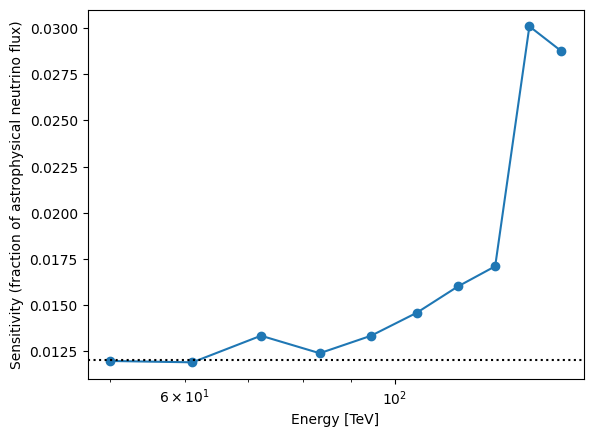

In [22]:
plt.plot(es, sensitivities, marker="o")
plt.axhline(0.012, color="black", linestyle="dotted", label="Analysis' sensitivity")
plt.xlabel("Energy [TeV]")
plt.ylabel("Sensitivity (fraction of astrophysical neutrino flux)")
plt.xscale("log")
plt.savefig("e_min_flaires_zoom", dpi=150)

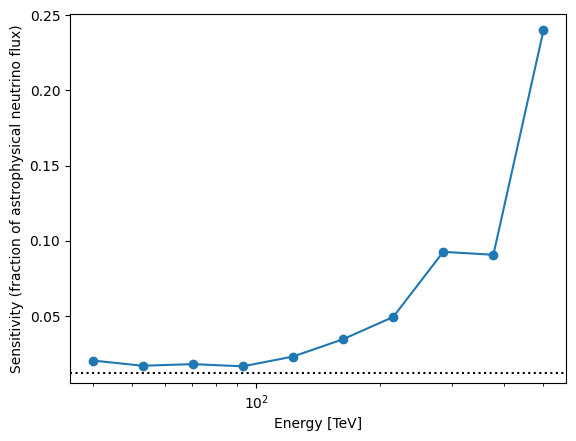

In [16]:
plt.plot(es, sensitivities, marker="o")
plt.axhline(0.012, color="black", linestyle="dotted", label="Analysis' sensitivity")
plt.xlabel("Energy [TeV]")
plt.ylabel("Sensitivity (fraction of astrophysical neutrino flux)")
plt.xscale("log")
plt.savefig("e_min_flaires", dpi=150)

In [37]:
agn_analysis = Analyse(
    AstrogeoAGNCatalogue(),
    [AverageFluxWeightHypothesis],
    HealpixNeutrinoAlertCatalogue(),
    cache_dir=os.getcwd(),
    min_E = 0,
    clean_cache=False
)

In [11]:
es = np.array([nu.energy for nu in agn_analysis.fixed_sources])
len(es), es

(365,
 array([ 161.  ,  134.  ,  139.  ,  154.  ,   85.  ,  237.  ,  109.  ,
         151.  ,  126.77,  105.  ,  126.  ,  126.  ,  109.  ,  161.47,
         416.  ,  116.  ,  115.  ,  122.  ,  122.  ,  106.  ,  123.  ,
         231.  ,  140.  ,   62.  ,  113.  ,  214.  ,  109.5 ,  163.  ,
         186.  ,  107.  ,   56.  ,  106.  ,  160.  ,  107.  ,  135.  ,
         107.  ,  208.  ,  184.  ,  439.  ,  144.  ,  110.  ,  110.  ,
         111.  ,  116.  ,  121.26,  208.  ,  168.  ,  193.  ,  202.  ,
         263.  ,  153.  ,  212.  ,  191.  ,  121.  ,  124.  , 3114.  ,
         143.  ,  133.  ,  267.79,   55.  ,  108.  ,  195.  ,  321.  ,
         114.  ,  133.  ,  108.  ,  109.  ,  961.  ,  216.  ,  217.  ,
         118.  ,  105.44,  155.  ,  155.  ,  228.  ,  218.  ,  188.  ,
         115.  ,  374.  ,  152.  ,  188.  ,  168.  ,  140.  ,  110.  ,
         139.  ,  198.  ,  161.  ,   55.  ,  128.  ,  113.  ,  373.  ,
         216.  ,  110.  ,  200.  ,  109.  ,  117.  ,  160.  ,  106.  ,


In [4]:
agn_analysis.set_injection_hypo(AverageFluxWeightHypothesis)

In [31]:
fraction = 0.06
n_steps = 10
n_trials = 100
progression_bar = True
additional_tag = "E_min_100"

fs = []
for step in np.linspace(0.0, fraction, n_steps + 1)[1:]:
    fs += [step for _ in range(n_trials)]

inputs = [(x, int(random.random() * 10 ** 8)) for x in fs]

if 'Healpix' not in type(agn_analysis.fixed_sources).__name__:
    if not progression_bar:
        text_trap = io.StringIO()
        sys.stderr = text_trap
        t0 = time.time()
    results = process_map(
        agn_analysis.run_trial_wrapper,
        inputs,
        max_workers=max_workers,
        chunksize=chunksize,
    )
    
else:
    results = []
    if progression_bar:
        for i in tqdm(range(len(inputs))):
            results.append(agn_analysis.run_trial(inputs[i][0],inputs[i][1]))
    else:
        t0 = time.time()
        for i in range(len(inputs)):
            results.append(agn_analysis.run_trial(inputs[i][0],inputs[i][1]))
if not progression_bar:
    sys.stderr = sys.__stderr__
    t1 = time.time()
    print(f"Job completed. Time taken:{(t1-t0)/3600} hours")

all_res = dict()

# Combine results into nested dictionaries

for fraction in sorted(list(set(fs))):
    mask = np.array(fs) == fraction
    cut_results = np.array(results)[mask]
    res_dict = cut_results[0]
    for entry in cut_results[1:]:
        for key, val in entry.items():
            res_dict[key] += val

    for key in res_dict.keys():
        res_dict[key] = np.array(res_dict[key])
    all_res[fraction] = res_dict

agn_analysis.all_res = all_res

agn_analysis.dump_results(additional_tag=additional_tag)

100%|██████████| 1000/1000 [08:48<00:00,  1.89it/s]


In [39]:
additional_tag = "E_min_0"
results = glob.glob(agn_analysis.cache_dir + "/" + additional_tag + "*")
new_res = results[0]
old_res = (
    "/data/user/gsommani/New_Updated_Alerts_Stacking/"
    "examples/radio_agn_neutrino_alert/cache/2025_10_27-10_16_09.pkl"
)
with open(new_res, "rb") as f:
    new_res_dict = pickle.load(f)
with open(old_res, "rb") as f:
    old_res_dict = pickle.load(f)

sens_threshold = dict()
for key, val in old_res_dict[0.].items():
    sens_threshold[key] = np.median(val)

In [43]:
levels = [
    ("Background Median", sens_threshold),
]

above = dict()

# Calculate for each step the fraction of trials that are above a certain threshold
# and store the information in the 'above' dictionary
for step, res in new_res_dict.items():

    bkgs = dict()
    temp = []

    for key, val in res.items():
        val = np.array(val)

        for name, thresh in levels:
            temp.append(np.sum(val > thresh[key])/float(len(val)))        
    above[step] = temp

fracs = list(above.keys())
sens = [list(above.values())[i][0] for i in range(len(fracs))]

# Interpolate a curve to the data points of the fraction of trials above each threshold
f1 = interpolate.interp1d(fracs, sens, kind='cubic')

# Calculate average signalness and number of neutrino alerts
tmp = [i.weight for i in agn_analysis.fixed_sources]
avg_signalness = np.mean(tmp)
n_events = len(tmp)

# Calculate flux needed to achieve sensitivity and discovery potential 
print(
    "\n------- Sensitivity and discovery potential with "
    "{0} neutrino alerts (average signalness: {1:.1f} %) --------\n".format(
        n_events, 100*avg_signalness
    )
)

x1 = bisect(lambda x: f1(x)-0.9, 0.006, 0.06, xtol=1e-6)

print("Sensitivity at {0:.3f} of flux, expectation of {1:.1f}/{2} = {3:.2f}".format(
            x1,(x1*avg_signalness)*n_events,n_events,(x1*avg_signalness)))
print("\n----------------------------------------------------------------------------------------------------------\n")


------- Sensitivity and discovery potential with 365 neutrino alerts (average signalness: 45.1 %) --------

Sensitivity at 0.033 of flux, expectation of 5.4/365 = 0.01

----------------------------------------------------------------------------------------------------------



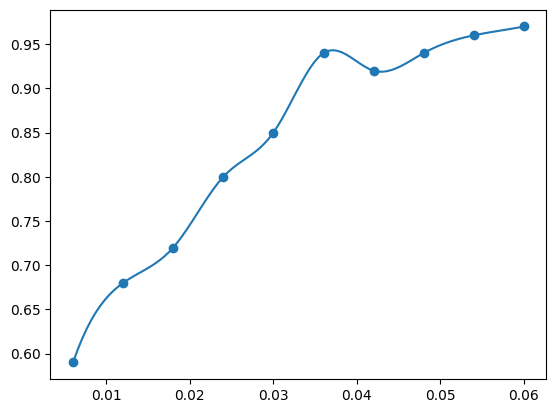

In [41]:
frs = np.linspace(min(fracs), max(fracs), 100)
plt.scatter(fracs, sens, marker="o")
plt.plot(frs, f1(frs))